In [21]:
from pathlib import Path
import osmnx as ox
import geopandas as gpd

# ── Config ─────────────────────────────────────────────────────────────────────
PLACE      = "Greater London, England"
EXPORT_DIR = Path("OSM_POI")
LSOA_PATH  = Path("geography") / "LSOA21_EW_BFC_V10.gpkg"

POI_LAYERS = [
    ("wet_venue",      [{"amenity": ["pub", "bar", "nightclub"]}]),
    ("latenight_food", [{"amenity": "fast_food"}]),
    ("off_licence",    [{"shop": "alcohol"}]),
    ("gambling",       [{"shop": "bookmaker"}, {"amenity": "casino"}, {"leisure": "amusement_arcade"}]),
    ("worship",        [{"amenity": "place_of_worship"}]),
]

OSM_COLS = [f"{name}_{suffix}"
            for name, _ in POI_LAYERS
            for suffix in ("count", "density_km2")]

# ── Helpers ────────────────────────────────────────────────────────────────────
def fetch_points(place, tags, crs):
    """Download OSM features and return as a point GeoDataFrame."""
    gdf = ox.features_from_place(place, tags)
    gdf["geometry"] = gdf.geometry.map(
        lambda g: g if g.geom_type == "Point" else g.centroid
    )
    return gdf[["geometry"]].to_crs(crs)


def count_per_lsoa(points, lsoa_gdf, id_col="LSOA21CD"):
    """Spatial join and count points per LSOA."""
    joined = gpd.sjoin(points, lsoa_gdf[[id_col, "geometry"]],
                       predicate="within", how="left")
    return joined.groupby(id_col).size()


# ── Load + prep LSOAs ─────────────────────────────────────────────────────────
LONDON_BOROUGHS = {
    "Barking and Dagenham", "Barnet", "Bexley", "Brent", "Bromley",
    "Camden", "City of London", "Croydon", "Ealing", "Enfield",
    "Greenwich", "Hackney", "Hammersmith and Fulham", "Haringey", "Harrow",
    "Havering", "Hillingdon", "Hounslow", "Islington",
    "Kensington and Chelsea", "Kingston upon Thames", "Lambeth", "Lewisham",
    "Merton", "Newham", "Redbridge", "Richmond upon Thames", "Southwark",
    "Sutton", "Tower Hamlets", "Waltham Forest", "Wandsworth", "Westminster",
}

lsoa = (gpd.read_file(LSOA_PATH)
          .to_crs(27700)
          .pipe(lambda df: df.assign(area_km2=df.area / 1e6))
          .pipe(lambda df: df[df["LSOA21NM"].str.extract(r"^(.+?)\s+\w+$")[0]
                               .isin(LONDON_BOROUGHS)])
          [["LSOA21CD", "LSOA21NM", "area_km2", "geometry"]]
          .reset_index(drop=True))

print(f"London LSOAs loaded: {len(lsoa):,}")

# ── Fetch POIs and compute counts/densities ────────────────────────────────────
EXPORT_DIR.mkdir(exist_ok=True)

for name, tag_groups in POI_LAYERS:
    print(f"Fetching: {name} ...")
    counts = sum(
        count_per_lsoa(fetch_points(PLACE, tags, lsoa.crs), lsoa)
        for tags in tag_groups
    ).rename(f"{name}_count")

    lsoa = lsoa.merge(counts, on="LSOA21CD", how="left")
    lsoa[f"{name}_count"]       = lsoa[f"{name}_count"].fillna(0).astype(int)
    lsoa[f"{name}_density_km2"] = lsoa[f"{name}_count"] / lsoa["area_km2"]

    print(f"  → total: {lsoa[f'{name}_count'].sum():,}")

# ── Export CSV (no geometry) ───────────────────────────────────────────────────
out_path = EXPORT_DIR / "london_lsoa_poi_density.csv"
(lsoa[["LSOA21CD", "LSOA21NM", "area_km2"] + OSM_COLS]
    .to_csv(out_path, index=False, encoding="utf-8-sig"))

print(f"\nSaved {len(lsoa):,} LSOAs → {out_path}")
print(lsoa[OSM_COLS].describe().round(4))

London LSOAs loaded: 4,994
Fetching: wet_venue ...
  → total: 4,542
Fetching: latenight_food ...
  → total: 6,178
Fetching: off_licence ...
  → total: 464
Fetching: gambling ...
  → total: 16
Fetching: worship ...
  → total: 3,285

Saved 4,994 LSOAs → OSM_POI\london_lsoa_poi_density.csv
       wet_venue_count  wet_venue_density_km2  latenight_food_count  \
count        4994.0000              4994.0000             4994.0000   
mean            0.9095                 4.9860                1.2371   
std             3.7324                13.1095                4.0575   
min             0.0000                 0.0000                0.0000   
25%             0.0000                 0.0000                0.0000   
50%             0.0000                 0.0000                0.0000   
75%             1.0000                 4.8774                1.0000   
max           168.0000               265.6090              188.0000   

       latenight_food_density_km2  off_licence_count  off_licence_densit

In [23]:
lsoa.columns

Index(['LSOA21CD', 'LSOA21NM', 'area_km2', 'geometry', 'wet_venue_count',
       'wet_venue_density_km2', 'latenight_food_count',
       'latenight_food_density_km2', 'off_licence_count',
       'off_licence_density_km2', 'gambling_count', 'gambling_density_km2',
       'worship_count', 'worship_density_km2'],
      dtype='object')

<Axes: >

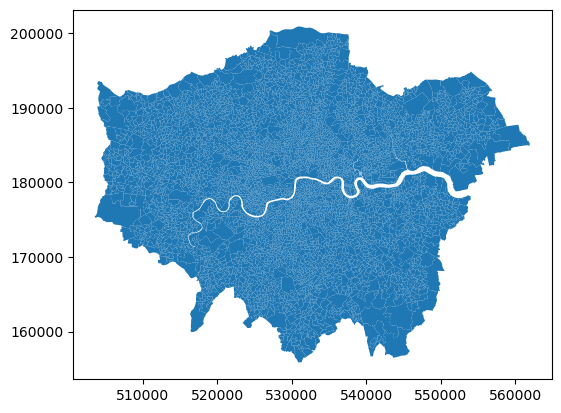

In [22]:
lsoa.plot()